# 非线性系统最优控制--目标函数可导的情况

本文档关注非线性系统的最优控制计算问题。我们考虑线性系统：
\begin{align*}
    & \dot{x}(t)=f\bigl(x(t),u(t)\bigr), \qquad x(0)=x_0 \in \mathcal{X}_0 \subseteq \mathbb{R}^n \\
    & J(x_0, u)=\int_0^T \ell\bigl(x(t),u(t)\bigr)\,d t+\Phi\bigl(x(T)\bigr).
\end{align*}
根据课程讲义，当我们利用神经网络$\pi_{\theta}(t,x)$来表征系统输入$u(t,x)$时，最优控制问题可以写为
\begin{align*}
    J^\text{tot}(\theta) = \mathbb{E}_{x_0\sim U(\mathcal X_0)}\left[ \tilde J(x_0, \theta)\right] 
\end{align*}
其中$\tilde J(x_0, \theta) \triangleq \int_0^T \ell\bigl(x(t),\pi_{\theta}(t,x(t))\bigr)\,d t+\Phi\bigl(x(T)\bigr)$。

为了说明方法，以及确认得到结果的最优性。我们依然用一个线性系统作为例子展示，但我们将它写成一般的形式，即我们设置
\begin{align*}
    f(x,u) = Ax+Bu, && \ell(x,u)= \bigl(x^\top Qx+u^\top Ru\bigr),
    && \Phi\bigl(x\bigr) = x^\top F x
\end{align*}
我们依旧选取：
\begin{align*}
&A = \begin{bmatrix} -0.7 & 0.5 \\ 1 & -1.5 \end{bmatrix},
&& B = \begin{bmatrix} 1 \\ 0.5 \end{bmatrix},
&& Q = \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix},
&& R = \begin{bmatrix} 1 \end{bmatrix},\\
& F = \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix},
&& x_0 = \begin{bmatrix} 1 \\ 1 \end{bmatrix}.
&& T = 10
\end{align*}
初始点落在$\mathcal X_0$区域$[1,2]\times[1,2]$上。

In [ ]:
# Required packages for this notebook: torch, matplotlib
# If needed, install them with: pip install torch matplotlib

import time
import torch
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.titlesize": 16,
})

In [2]:
T = 10
dt = 0.01
x0 = torch.tensor([[[1.], [1.]]])  # (batch_size, state_dim, 1)
A = torch.tensor([[-0.7, 0.5], [1., -1.5]])
B = torch.tensor([[1.], [0.5]])
Q = torch.eye(2)
R = torch.eye(1)
F = torch.tensor([[1., 0.], [0., 1.]])


def f(x,u):     # 可以根据需要修改为非线性系统
    # x: (batch_size, state_dim, 1)
    # u: (batch_size, control_dim, 1)
    return A @ x + B @ u

def ell(x,u):   # 可以根据需要修改为非线性系统
    return x.transpose(-2,-1) @ Q @ x + u.transpose(-2,-1) @ R @ u

def Phi(x):     # 可以根据需要修改为非线性系统
    return x.transpose(-2,-1) @ F @ x

def u(t,x):
    # 这里是一个简单的线性控制器示例，可以根据需要替换为更复杂的神经网络控制器
    return torch.zeros(x.shape[0], 1, 1)  # (batch_size, control_dim, 1)


def simulate_system(f, ell, Phi, x0, u, T, dt):
    """Simulate the continuous-time system with forward Euler. Supports batched x0."""
    # x0: (state_dim, 1) 或 (batch_size, state_dim, 1)
    # u: function of (t, x)
    batched = x0.dim() == 3
    if not batched:
        x0 = x0.unsqueeze(0)  # (1, state_dim, 1)

    batch_size = x0.shape[0]
    state_dim = x0.shape[1]
    num_steps = int(T / dt)

    time_grid = torch.linspace(0.0, num_steps * dt, num_steps + 1)
    x = torch.zeros(batch_size, num_steps + 1, state_dim, dtype=x0.dtype)
    x[:, 0] = x0.squeeze(-1)
    pre_x = x0  # (batch, state_dim, 1)
    J = torch.zeros(batch_size, 1, 1, dtype=x0.dtype)

    # Simulate the system forward in time using forward Euler integration
    for k in range(num_steps):
        t = k * dt
        control = u(t, pre_x)
        J = J + ell(pre_x, control) * dt
        state_derivative = f(pre_x, control)
        pre_x = pre_x + dt * state_derivative
        x[:, k + 1] = pre_x.squeeze(-1)
    
    J = J + Phi(pre_x) # Add terminal cost

    if not batched:
        x = x.squeeze(0)   # (num_steps+1, state_dim)
        J = J.squeeze(0)   # (1, 1)

    return time_grid, x, J

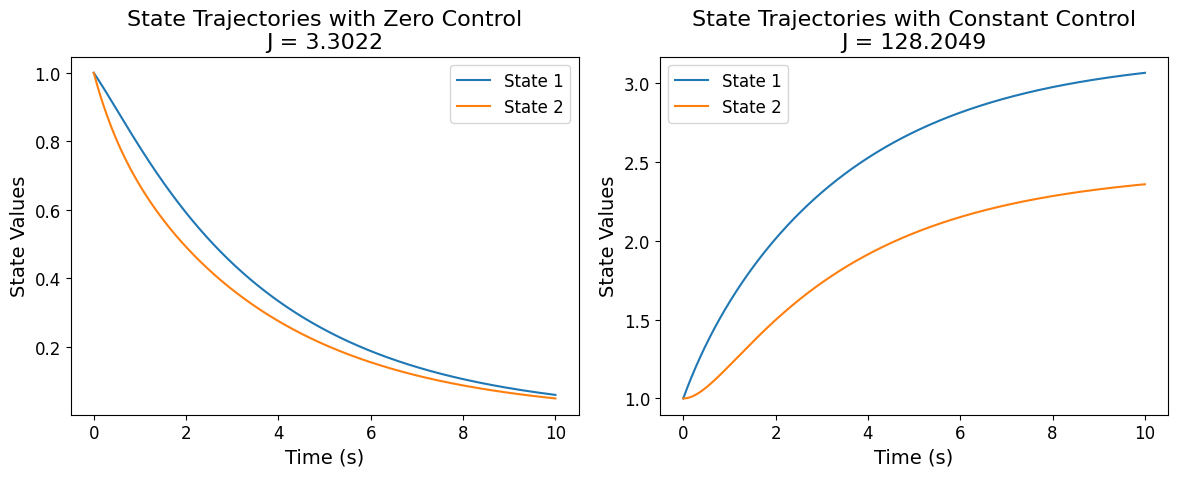

In [3]:
# plottting the simulation results

def u_zero(t, x):
    return torch.zeros(x.shape[0], 1, 1)  # (batch_size, control_dim, 1)
time_grid_zero, x_zero, J_zero = simulate_system(f, ell, Phi, x0, u_zero, T, dt)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(time_grid_zero, x_zero[0, :, 0], label='State 1')
plt.plot(time_grid_zero, x_zero[0, :, 1], label='State 2')
plt.title(f'State Trajectories with Zero Control\nJ = {J_zero[0].item():.4f}')
plt.xlabel('Time (s)')
plt.ylabel('State Values')
plt.legend()

def u_const(t, x):
    return torch.ones(x.shape[0], 1, 1)  # Example constant control input
time_grid_const, x_const, J_const = simulate_system(f, ell, Phi, x0, u_const, T, dt)

plt.subplot(1, 2, 2)
plt.plot(time_grid_const, x_const[0, :, 0], label='State 1')
plt.plot(time_grid_const, x_const[0, :, 1], label='State 2')
plt.title(f'State Trajectories with Constant Control\nJ = {J_const[0].item():.4f}')
plt.xlabel('Time (s)')
plt.ylabel('State Values')
plt.legend()

plt.tight_layout()
plt.show()


## 基于梯度下降的直接计算方法

我们可以利用梯度下降的方法，直接学习最优的神经网络参数，从而近似最优控制策略。

In [4]:
import torch.nn as nn

# 定义神经网络控制器，输入 (t, x)，输出 u
class NeuralController(nn.Module):
    def __init__(self, state_dim, control_dim, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim + 1, hidden_dim),  # +1 for time
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, control_dim),
        )

    def forward(self, t, x):
        # t: (batch_size,) 或 (batch_size, 1) 或 float
        # x: (batch_size, state_dim, 1)
        if isinstance(t, float) or isinstance(t, int):
            t = torch.ones(x.size(0), 1, dtype=x.dtype, device=x.device) * t  # (batch_size, 1)
        elif t.dim() == 1:
            t = t.unsqueeze(-1)  # (batch_size, 1)
        x_flat = x.squeeze(-1)  # (batch_size, state_dim)
        input_tensor = torch.cat([t, x_flat], dim=-1)  # (batch_size, state_dim + 1)
        u = self.net(input_tensor)  # (batch_size, control_dim)
        return u.unsqueeze(-1)  # (batch_size, control_dim, 1)
        


state_dim = A.shape[0]
control_dim = B.shape[1]
policy = NeuralController(state_dim, control_dim, hidden_dim=32) # 可以根据需要调整隐藏层大小
optimizer = torch.optim.Adam(policy.parameters(), lr=1e-3) 

num_epochs = 300
loss_history = []
batch_size = 100

start_time = time.perf_counter() # 记录训练开始时间

# 训练神经网络控制器
for epoch in range(num_epochs):
    optimizer.zero_grad()

    # x_0 采样，在[1,2]x[1,2]的区域内随机采样初始状态
    x0_batch = 1 + torch.rand(batch_size, state_dim, 1)  # (batch_size, state_dim, 1)

    # 前向仿真，计算代价
    time_grid_train, x_train, J_train = simulate_system(
        f, ell, Phi, x0_batch, policy, T, dt
    )
    loss = J_train.mean()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 30 == 0:
        print(f"epoch={epoch:4d}, J={loss.item():.6f}")

elapsed_nn = time.perf_counter() - start_time

print("-" * 50)
print(f"final cost J = {loss_history[-1]:.6f}")
print(f"elapsed time  = {elapsed_nn:.4f} s")

epoch=   0, J=21.279566
epoch=  30, J=4.834440
epoch=  60, J=3.814572
epoch=  90, J=3.468472
epoch= 120, J=3.105194
epoch= 150, J=3.057852
epoch= 180, J=3.164157
epoch= 210, J=3.073278
epoch= 240, J=3.188396
epoch= 270, J=3.135008
--------------------------------------------------
final cost J = 3.242543
elapsed time  = 139.6299 s


接下来，我们把结果和理论最优控制进行比较

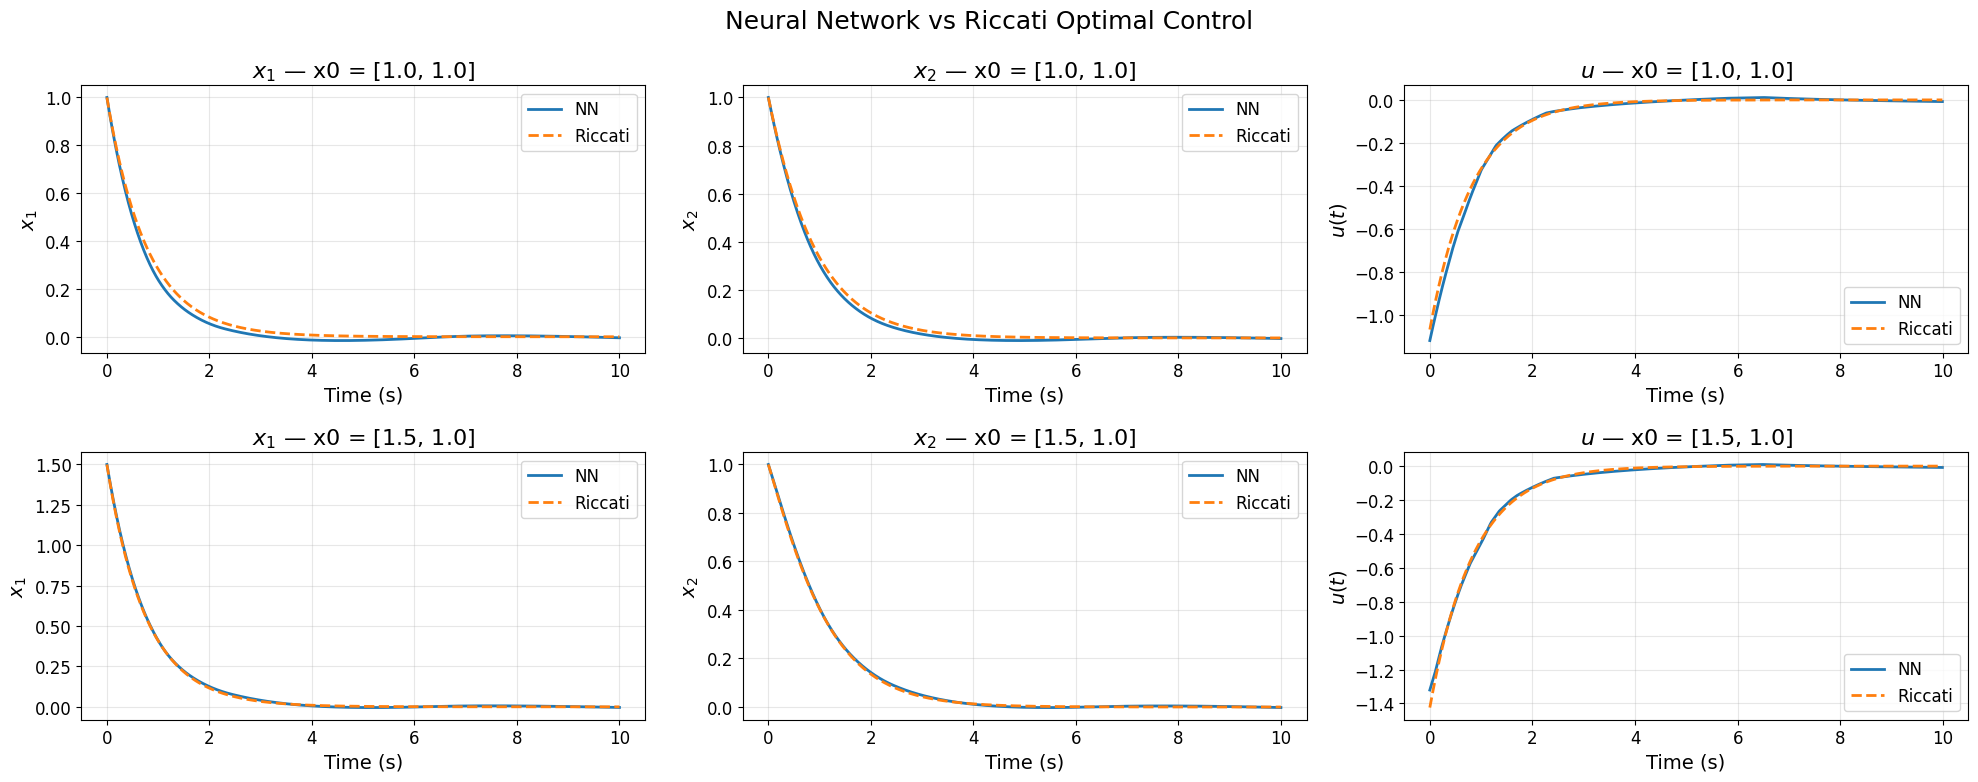

初始条件                    NN J    Riccati J         相对误差
-------------------------------------------------------
x0 = [1.0, 1.0]       1.3555       1.3452       0.76 %
x0 = [1.5, 1.0]       2.3086       2.3069       0.07 %


In [6]:
X0 = torch.tensor([[[1.], [1.]],
                   [[1.5], [1.]]])  # (2, state_dim, 1)

# 仿真训练好的神经网络控制器
with torch.no_grad():
    time_grid_nn, x_nn, J_nn = simulate_system(f, ell, Phi, X0, policy, T, dt)

# 基于Ricatti方程的最优控制
P = torch.load("Results/riccati_solution.pt") # 读取之前保存的Ricatti方程的解
def u_riccati(t, x):
    position = int(t // dt)
    return -torch.linalg.inv(R) @ B.transpose(-2, -1) @ P[position] @ x
time_grid_riccati, x_riccati, J_riccati = simulate_system(f, ell, Phi, X0, u_riccati, T, dt)


# 计算两组初始条件下的控制输入
num_steps = int(T / dt)
control_time = time_grid_nn[:-1]
u_nn_traj = torch.zeros(2, num_steps, control_dim)
u_ric_traj = torch.zeros(2, num_steps, control_dim)
with torch.no_grad():
    for i in range(2):
        for k in range(num_steps):
            t_k = k * dt
            x_k_nn = x_nn[i, k].unsqueeze(0).unsqueeze(-1)   # (1, state_dim, 1)
            u_nn_traj[i, k] = policy(t_k, x_k_nn).squeeze()
            x_k_ric = x_riccati[i, k].unsqueeze(-1)           # (state_dim, 1)
            u_ric_traj[i, k] = u_riccati(t_k, x_k_ric).squeeze()

# 绘制比较图：每个初始条件一行，3列（x1, x2, u）
labels_x0 = [f"x0 = {X0[i].squeeze(-1).tolist()}" for i in range(X0.shape[0])]
fig, axes = plt.subplots(2, 3, figsize=(20, 8))

for i in range(2):
    # x1
    axes[i, 0].plot(time_grid_nn, x_nn[i, :, 0], label='NN', linewidth=2)
    axes[i, 0].plot(time_grid_riccati, x_riccati[i, :, 0], '--', label='Riccati', linewidth=2)
    axes[i, 0].set_title(f'$x_1$ — {labels_x0[i]}')
    axes[i, 0].set_xlabel('Time (s)')
    axes[i, 0].set_ylabel('$x_1$')
    axes[i, 0].legend()
    axes[i, 0].grid(True, alpha=0.3)

    # x2
    axes[i, 1].plot(time_grid_nn, x_nn[i, :, 1], label='NN', linewidth=2)
    axes[i, 1].plot(time_grid_riccati, x_riccati[i, :, 1], '--', label='Riccati', linewidth=2)
    axes[i, 1].set_title(f'$x_2$ — {labels_x0[i]}')
    axes[i, 1].set_xlabel('Time (s)')
    axes[i, 1].set_ylabel('$x_2$')
    axes[i, 1].legend()
    axes[i, 1].grid(True, alpha=0.3)

    # u
    axes[i, 2].plot(control_time, u_nn_traj[i, :, 0], label='NN', linewidth=2)
    axes[i, 2].plot(control_time, u_ric_traj[i, :, 0], '--', label='Riccati', linewidth=2)
    axes[i, 2].set_title(f'$u$ — {labels_x0[i]}')
    axes[i, 2].set_xlabel('Time (s)')
    axes[i, 2].set_ylabel('$u(t)$')
    axes[i, 2].legend()
    axes[i, 2].grid(True, alpha=0.3)

plt.suptitle('Neural Network vs Riccati Optimal Control', fontsize=18)
plt.tight_layout()
plt.show()

# 打印代价对比
print(f"{'初始条件':<15} {'NN J':>12} {'Riccati J':>12} {'相对误差':>12}")
print("-" * 55)
for i in range(2):
    j_nn = J_nn[i].item()
    j_ric = J_riccati[i].item()
    rel_err = abs(j_nn - j_ric) / abs(j_ric) * 100
    print(f"{labels_x0[i]:<15} {j_nn:>12.4f} {j_ric:>12.4f} {rel_err:>10.2f} %")